In [1]:
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import pickle
import os
import matplotlib.pyplot as plt
import numpy as np
import jax
import jax.numpy as jnp

PKLs = []
PKL_titles = []
DIR = "./dim5/"
for file in os.listdir(DIR):
    if file.endswith(".pkl"):
        PKLs.append(pickle.load(open(DIR+file, "rb")))
        PKL_titles.append(str(file))
n = len(PKLs)
plt.rcParams['text.usetex'] = False

env: XLA_PYTHON_CLIENT_PREALLOCATE=False


In [3]:
import numpy as np
print("res[3] shape (reps, T+1, p):", np.asarray(PKLs[0]['res'][3]).shape)
print("tempering λ_t:", np.asarray(PKLs[0]['res'][6])[0])
print("repetitions:", np.asarray(PKLs[0]['res'][3]).shape[0])

res[3] shape (reps, T+1, p): (10, 16, 1)
tempering λ_t: [0.11924805 0.23894238 0.47337952 0.8224117  1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.        ]
repetitions: 10


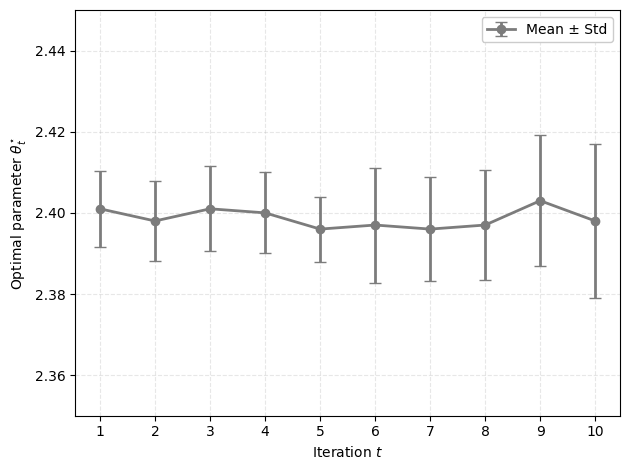

In [2]:

# Define color scheme
grays = [
    "#EAEAEA",  # Lightest gray
    "#D4D4D4",
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424"   # Darkest gray
]

# Plot parameters evolution
idx = 0
max_iterations = 10
x_axis = range(1, max_iterations + 1)
all_parameters = PKLs[idx]['res'][3][:, :max_iterations]

# Main plot with error bars
plt.errorbar(x_axis, 
            np.mean(all_parameters, axis=0).squeeze(), 
            np.std(all_parameters, axis=0).squeeze(),
            color=grays[5],  # Mid-gray color
            linewidth=2,
            marker='o',
            markersize=6,
            capsize=4,
            label='Mean ± Std')

# Optional: Individual runs (commented out as per your 'if False' condition)
# for run in range(PKLs[idx]['res'][3].shape[0]):
#     plt.plot(x_axis, 
#              PKLs[idx]['res'][3][run, :max_iterations], 
#              alpha=0.2,
#              color=grays[2])

# Reference line at optimal value
# plt.axhline(y=2.38, xmin=0, xmax=1, 
#            linewidth=1.5, 
#            color='k', 
#            linestyle='--',
#            alpha=0.7,
#            label='Optimal value')

# Plot formatting
plt.ylabel(r'Optimal parameter $\theta_t^{\star}$')
plt.xlabel(r'Iteration $t$')
plt.ylim(2.35, 2.45)
plt.xticks(x_axis)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(framealpha=1, frameon=True)

plt.tight_layout()
plt.savefig(DIR + "RW_optimal_parameter.pdf", bbox_inches='tight')

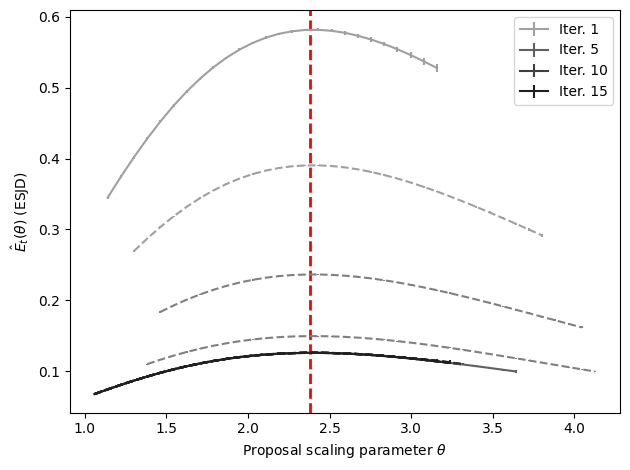

In [3]:

GRID_ESJD = jnp.linspace(0.01, 8, 100)

grays = [
    "#EAEAEA",  # Lightest gray
    "#D4D4D4",
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424"   # Darkest gray
]

grays_darker = [
    "#D4D4D4",  # New lightest gray (originally #D4D4D4)
    "#BEBEBE",
    "#A8A8A8",
    "#929292",
    "#7C7C7C",
    "#666666",
    "#505050",
    "#3A3A3A",
    "#242424",
    "#0F0F0F"   # New darkest gray (darker than #242424)
]

grays_dark = [
    "#A0A0A0",  # New lightest gray (much darker than original)
    "#808080",  # Mid-gray
    "#606060",
    "#505050",
    "#404040",
    "#303030",
    "#282828",
    "#202020",
    "#181818",
    "#101010",   # Almost black
    "#080808"    # Near-black
]

idx = 0

criteria_function = PKLs[idx]['res'][5].mean(axis=0) 
stds = jax.vmap(lambda x: x.std(axis=-1))(PKLs[idx]['res'][5].T).T

for j in range(PKLs[idx]['res'][5].shape[1]):
    plt.errorbar(GRID_ESJD, criteria_function[j], yerr=stds[j], label=f"Iter. {str(j+1)}" if j in [0, 4, 9, 14, 19] else None, color=grays_dark[j//2], linestyle="solid" if  j in [0, 4, 9, 14, 19] else "--")
plt.axvline(x=2.38, ymin=0, ymax = 1, linewidth=2, linestyle="--", color='r')
plt.legend()
plt.ylabel(r"$\hat{E}_t(\theta)$ (ESJD)")
plt.xlabel(r'Proposal scaling parameter $\theta$')

plt.tight_layout()  # Prevent label clipping
plt.savefig(DIR + f"{PKL_titles[idx]}criteria_function.pdf", bbox_inches='tight')

